# EuroSAT Land Cover Classification: Processing & Recognition

**Team:** Aleksandra Szpakowska, Wojciech Hrycenko  
**Courses:** Image Processing | Image Recognition

## Project Objective
This notebook implements a comparative analytical pipeline for satellite imagery classification using the **EuroSAT (RGB)** dataset. The study evaluates the impact of advanced image processing and feature extraction against deep learning architectures in the context of socio-economic land use monitoring.

## Analytical Pipeline
1. **Exploratory Data Analysis (EDA):** Dataset inspection and class distributions.
2. **Track A (Classical ML):** Image enhancement (Histogram Equalization, Bilateral Filter) -> Feature Extraction (HOG, LBP, Color Histograms) -> Classification (Random Forest/XGBoost).
3. **Track B (Deep Learning):** Data augmentation -> Transfer Learning (CNN) -> Fine-tuning.
4. **Evaluation:** Performance comparison using precision, recall, F1-score, and confusion matrices.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from skimage import feature, exposure
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

plt.style.use('seaborn-v0_8-whitegrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = './data'

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()

## 1. Exploratory Data Analysis (EDA)
Verifying dataset structure, class distribution, and visualizing sample satellite images across different land cover categories.

,Class,Image_Count
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Residential,3000
4,SeaLake,3000
5,Highway,2500
6,PermanentCrop,2500
7,Industrial,2500
8,River,2500
9,Pasture,2000


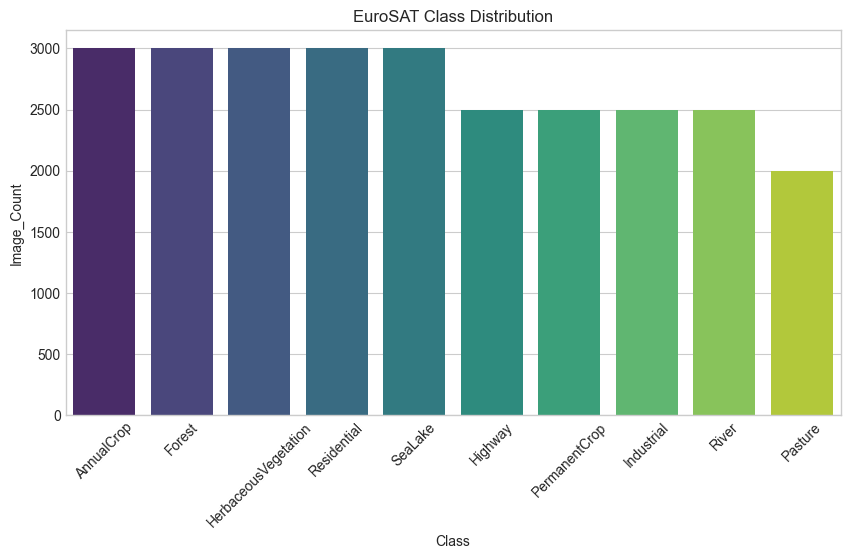

In [ ]:
def check_dataset_distribution(data_dir):
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    
    df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Image_Count'])
    df = df.sort_values('Image_Count', ascending=False).reset_index(drop=True)
    return df

df_distribution = check_dataset_distribution(DATA_DIR)
display(df_distribution)

plt.figure(figsize=(10, 5))
# Updated: assigned hue and legend=False to resolve the warning
sns.barplot(
    data=df_distribution, 
    x='Class', 
    y='Image_Count', 
    hue='Class', 
    palette='viridis', 
    legend=False
)
plt.xticks(rotation=45)
plt.title('EuroSAT Class Distribution')
plt.show()

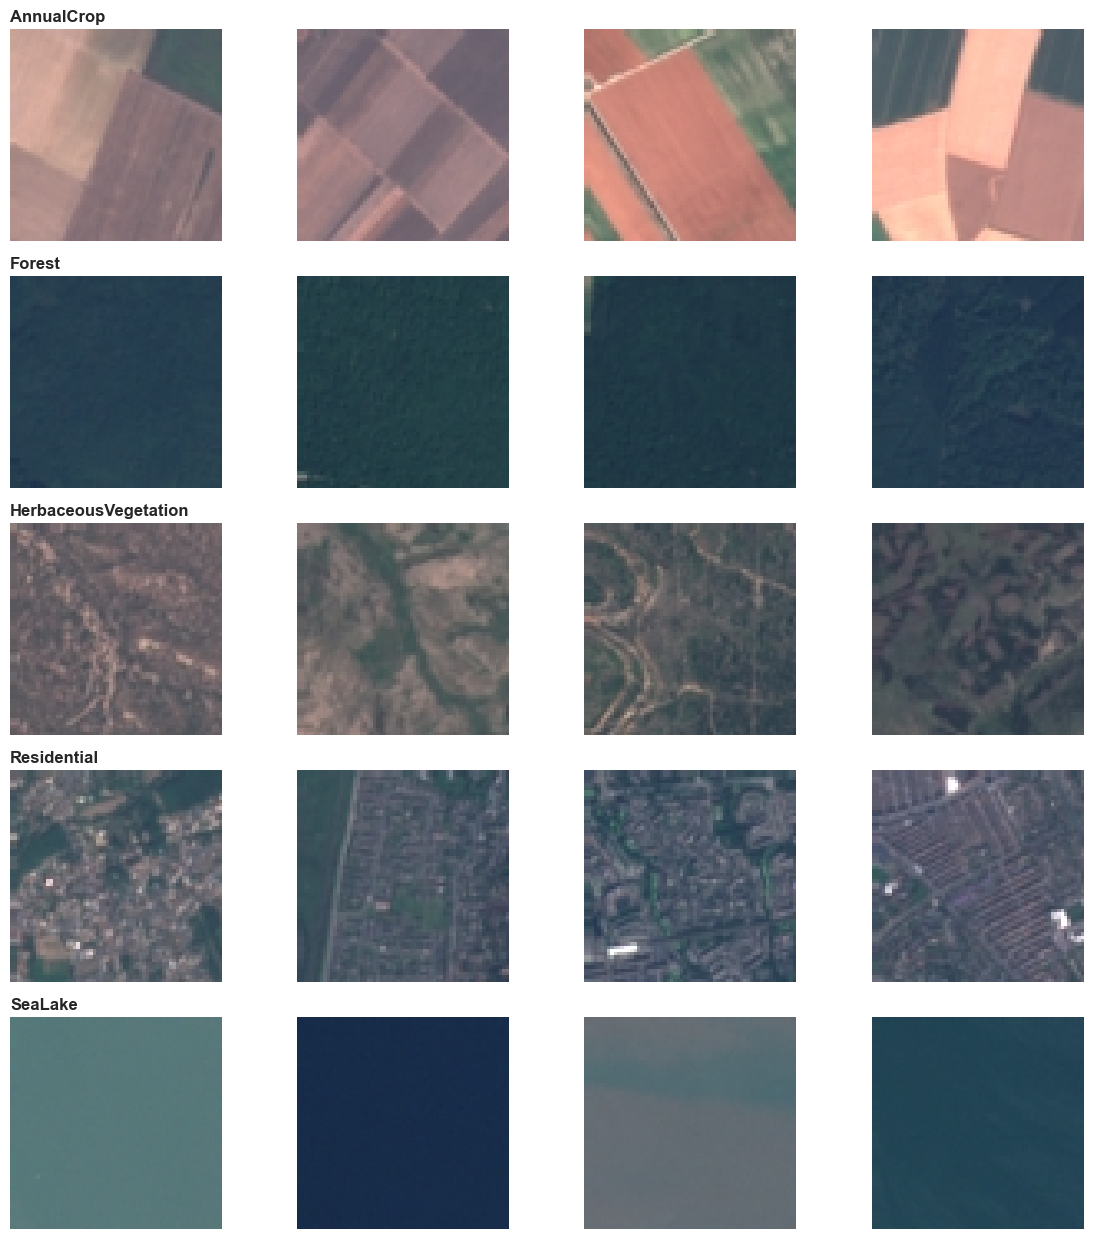

In [3]:
def plot_class_samples(data_dir, classes, samples_per_class=4):
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(12, 2.5 * len(classes)))
    
    for i, cls in enumerate(classes):
        cls_path = os.path.join(data_dir, cls)
        img_names = random.sample(os.listdir(cls_path), samples_per_class)
        
        for j, img_name in enumerate(img_names):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            ax = axes[i, j]
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(cls, fontsize=12, fontweight='bold', loc='left')
                
    plt.tight_layout()
    plt.show()

plot_class_samples(DATA_DIR, df_distribution['Class'].tolist()[:5])

### 1.1 Image Processing Laboratory: Multidimensional Feature Extraction

In this section, we apply a comprehensive suite of classical image processing techniques from the course syllabus to extract structural, textural, and spectral features from EuroSAT satellite imagery. Our goal is to demonstrate how low-level pixel manipulations prepare data for high-level recognition. We explore:

* **Spatial Domain Analysis:** Utilizing **Gaussian filtering** for noise reduction, followed by **Canny Edge Detection** and **Morphological operations** (Dilation, Erosion, Closing). This allows us to isolate geometric shapes and assess the structural continuity of man-made objects like roads and buildings.
* **Frequency Domain Analysis:** Applying the **2D Fast Fourier Transform (FFT)** to shift from pixel intensities to spatial frequencies. By analyzing the **Magnitude Spectrum**, we distinguish between structured urban areas (characterized by directional energy spikes) and stochastic natural textures like forests (characterized by omnidirectional energy distribution).
* **Point Operations & Histogram Enhancement:** Implementing **CLAHE (Contrast Limited Adaptive Histogram Equalization)** to normalize lighting conditions. This step is crucial for satellite data, as it amplifies subtle textural details and enhances local contrast without over-amplifying sensor noise.
* **Color Space & Adaptive Segmentation:** Transforming data into the **HSV (Hue, Saturation, Value)** space and applying **Otsu’s Binarization**. This demonstrates the limitations of global thresholding in the face of spectral mixing and seasonal vegetation changes.
* **Geometric Transformations & Interpolation:** Examining the impact of **Scaling** and pixel estimation methods. By comparing **Nearest Neighbor** vs. **Bicubic Interpolation**, we visualize the inherent resolution limits of the Sentinel-2 sensors and the "aliasing" artifacts that occur during image upsampling.

--- Image Processing Syllabus Application ---


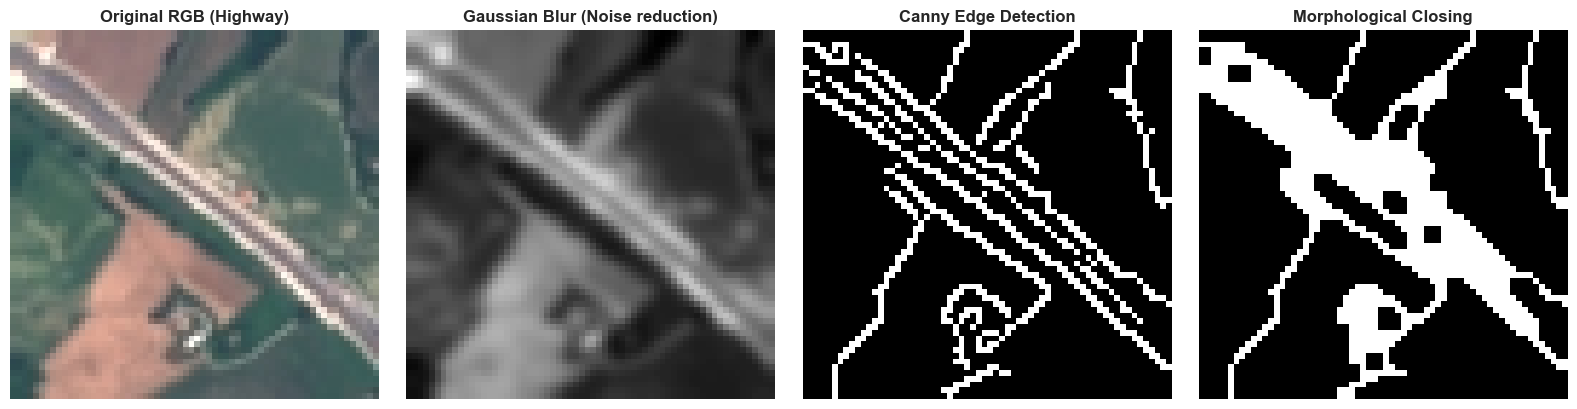

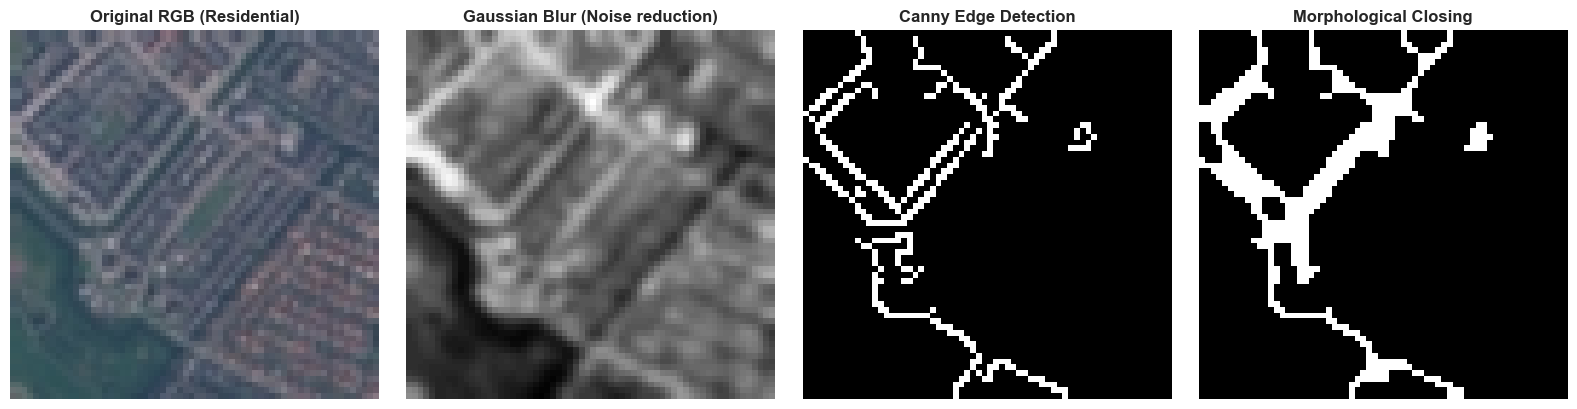

In [ ]:
def advanced_image_processing_showcase(data_dir, class_name='Highway'):
    """
    Demonstrates syllabus-aligned image processing techniques:
    Grayscale conversion, Gaussian Blur, Canny Edge Detection, and Morphological Operations.
    """
    class_path = os.path.join(data_dir, class_name)
    img_name = os.listdir(class_path)[0] # Bierzemy pierwsze zdjęcie z brzegu
    img_bgr = cv2.imread(os.path.join(class_path, img_name))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # 1. Grayscale & Noise Reduction
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # 2. Edge Detection (Canny) - świetne do wykrywania dróg i budynków
    edges = cv2.Canny(blurred, threshold1=50, threshold2=150)
    
    # 3. Morphological Operations (Dilation + Erosion = Closing)
    # Zamykanie przerw w wykrytych krawędziach autostrad
    kernel = np.ones((3,3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=1)
    morph_closed = cv2.erode(dilated, kernel, iterations=1)
    
    # Visualization
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original RGB ({class_name})', fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(blurred, cmap='gray')
    axes[1].set_title('Gaussian Blur (Noise reduction)', fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(edges, cmap='gray')
    axes[2].set_title('Canny Edge Detection', fontweight='bold')
    axes[2].axis('off')
    
    axes[3].imshow(morph_closed, cmap='gray')
    axes[3].set_title('Morphological Closing', fontweight='bold')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()

print("--- Image Processing Syllabus Application ---")
advanced_image_processing_showcase(DATA_DIR, class_name='Highway')
advanced_image_processing_showcase(DATA_DIR, class_name='Residential')

--- Frequency Domain Exploration ---


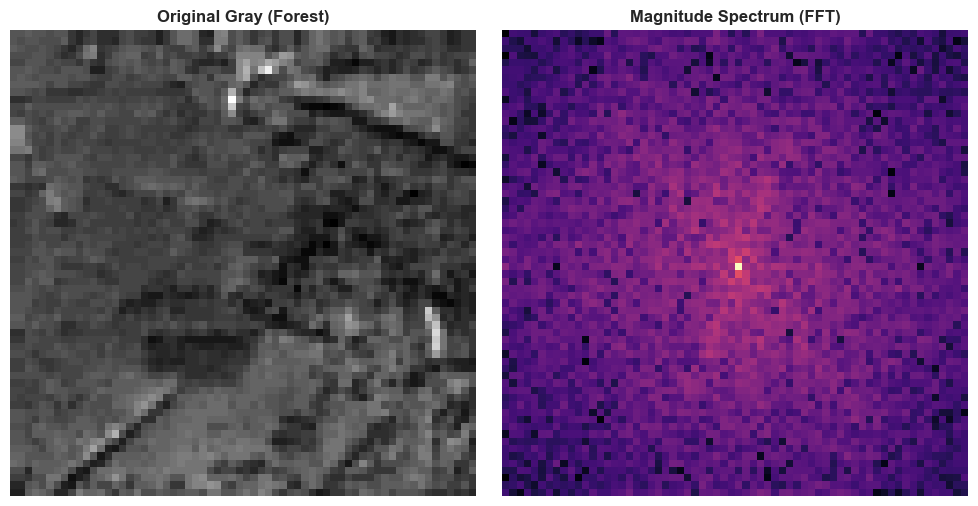

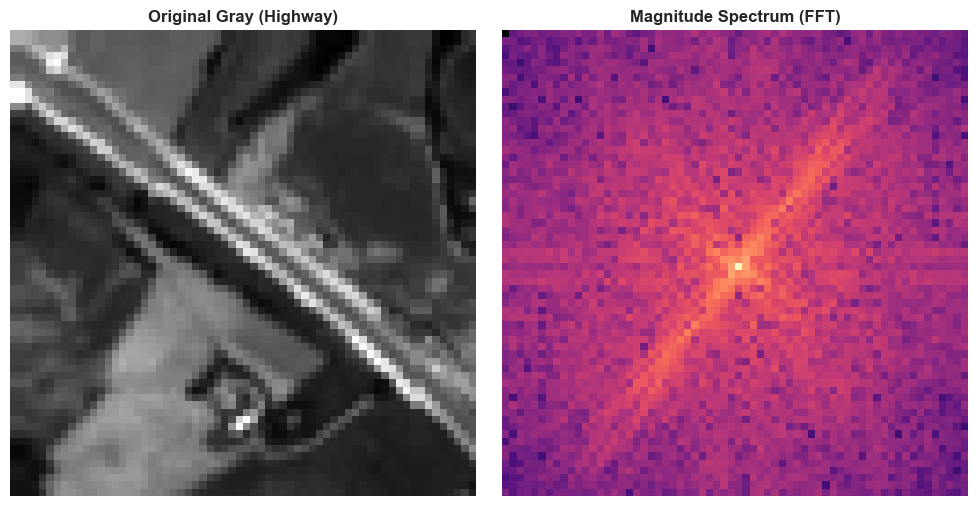

In [7]:
def frequency_analysis_showcase(data_dir, class_name='Forest'):
    """
    Demonstrates Frequency Domain analysis using Fast Fourier Transform (FFT).
    Helps distinguish between textures (Forest/Crop) and structural shapes (Highway/Residential).
    """
    class_path = os.path.join(data_dir, class_name)
    img_name = os.listdir(class_path)[0]
    img = cv2.imread(os.path.join(class_path, img_name), 0) # Load as grayscale
    
    # Compute FFT
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Original Gray ({class_name})', fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(magnitude_spectrum, cmap='magma')
    axes[1].set_title('Magnitude Spectrum (FFT)', fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

print("--- Frequency Domain Exploration ---")
frequency_analysis_showcase(DATA_DIR, class_name='Forest')    # High entropy, spread spectrum
frequency_analysis_showcase(DATA_DIR, class_name='Highway')   # Linear energy distribution

--- Robust Color Segmentation Lab ---


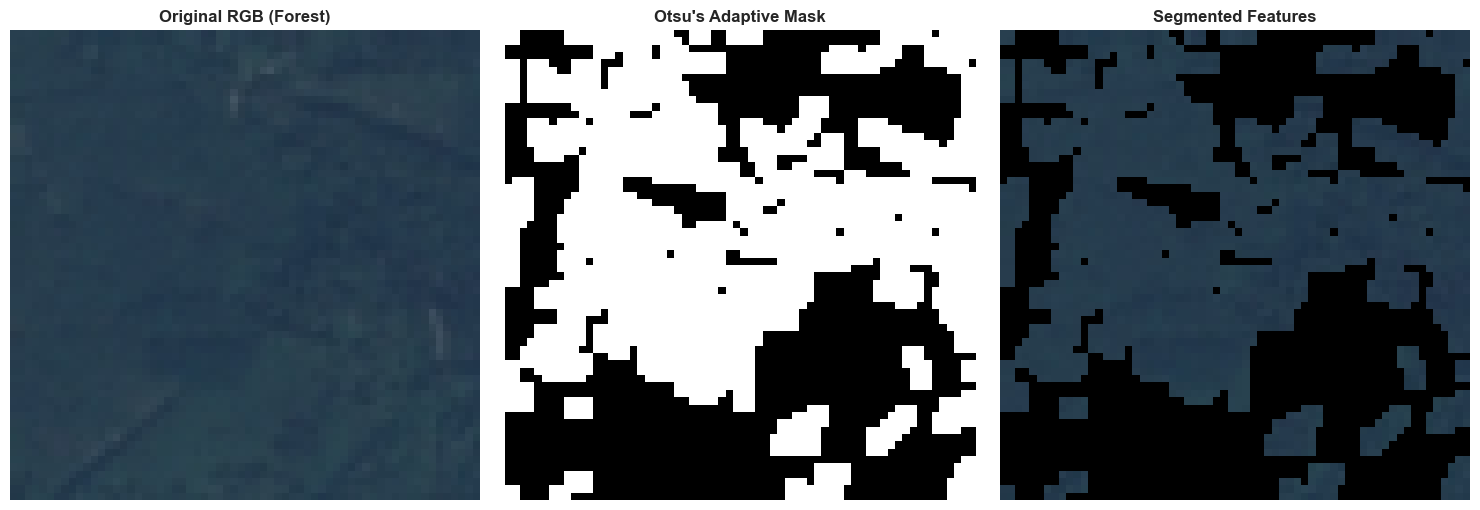

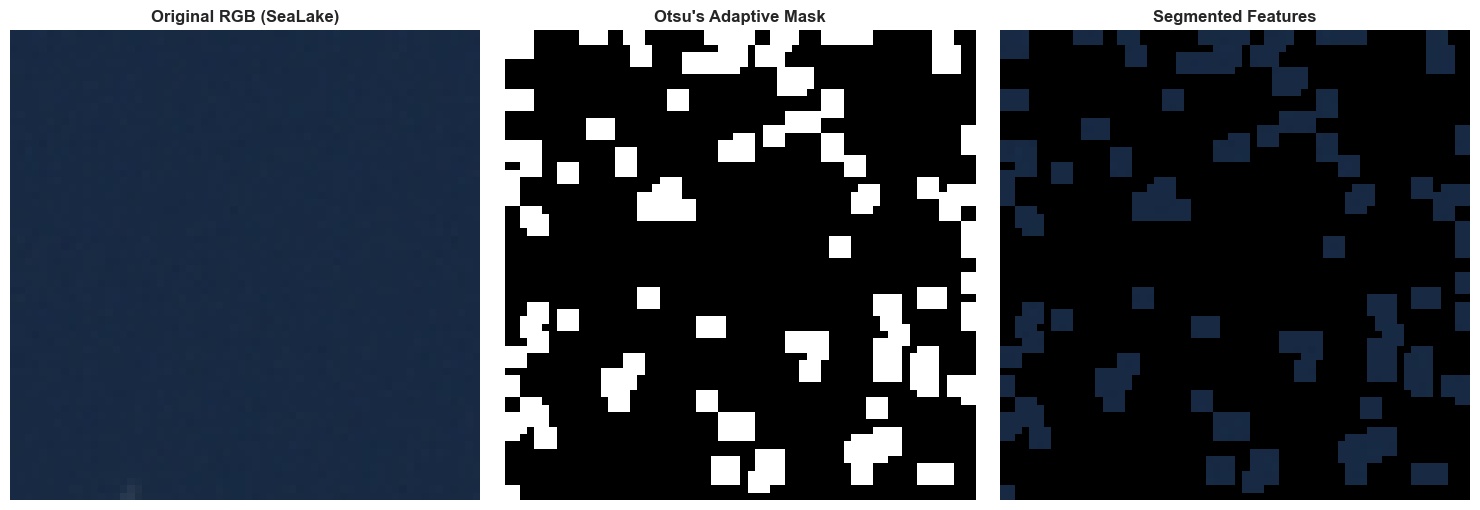

In [10]:
def color_segmentation_showcase(data_dir, class_name='Forest'):
    """
    Improved segmentation using HSV space and Otsu's automatic thresholding.
    This method is more robust to different lighting conditions in satellite imagery.
    """
    class_path = os.path.join(data_dir, class_name)
    img_name = os.listdir(class_path)[0]
    img_bgr = cv2.imread(os.path.join(class_path, img_name))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Switch to HSV
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    
    # Use Otsu's Binarization on the Saturation channel 
    # (Vegetation and water usually have distinct saturation levels)
    _, mask = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Optional: Clean up noise with Morphological Opening (from our syllabus!)
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    segmented = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original RGB ({class_name})', fontweight='bold')
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Otsu's Adaptive Mask", fontweight='bold')
    axes[2].imshow(segmented)
    axes[2].set_title('Segmented Features', fontweight='bold')
    
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

print("--- Robust Color Segmentation Lab ---")
color_segmentation_showcase(DATA_DIR, class_name='Forest')
color_segmentation_showcase(DATA_DIR, class_name='SeaLake') # Spróbuj na jeziorze, Otsu świetnie odcina wodę!

--- Histogram & Contrast Enhancement Lab ---


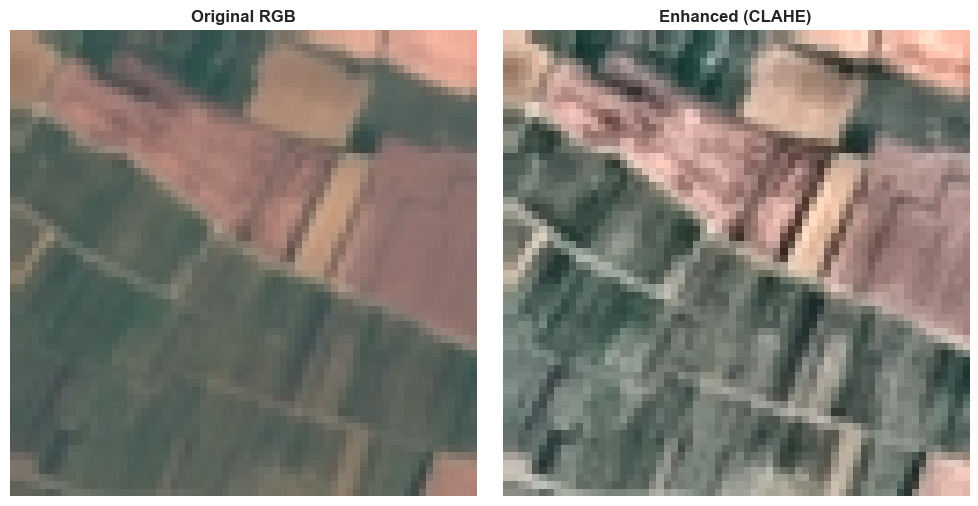

In [11]:
def histogram_enhancement_showcase(data_dir, class_name='PermanentCrop'):
    """
    Demonstrates CLAHE (Contrast Limited Adaptive Histogram Equalization).
    Essential for normalizing lighting and enhancing texture details in satellite data.
    """
    class_path = os.path.join(data_dir, class_name)
    img_name = os.listdir(class_path)[0]
    img_bgr = cv2.imread(os.path.join(class_path, img_name))
    img_yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)
    
    # Apply CLAHE to the Luma (Y) channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_yuv[:,:,0] = clahe.apply(img_yuv[:,:,0])
    
    img_enhanced = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
    img_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_original)
    axes[0].set_title('Original RGB', fontweight='bold')
    axes[1].imshow(img_enhanced)
    axes[1].set_title('Enhanced (CLAHE)', fontweight='bold')
    
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

print("--- Histogram & Contrast Enhancement Lab ---")
histogram_enhancement_showcase(DATA_DIR, class_name='PermanentCrop')

--- Geometric Transformations Lab ---


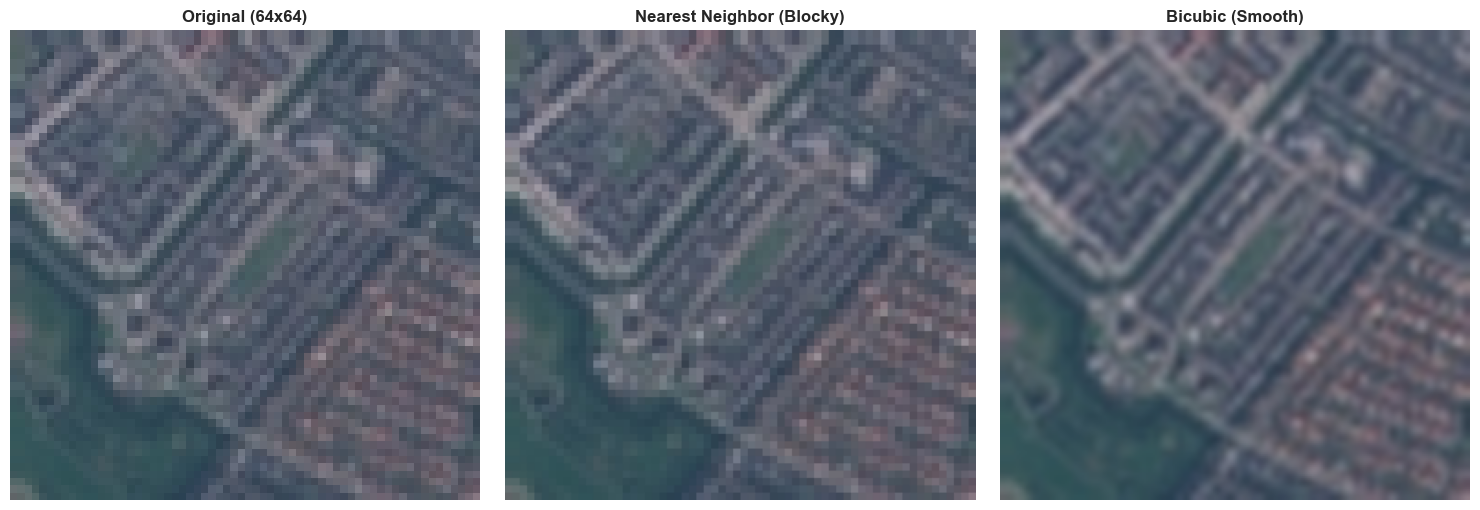

In [14]:
def interpolation_showcase(data_dir, class_name='Residential'):
    """
    Demonstrates Geometric Transformations (Scaling) and Interpolation methods 
    from the lecture (Nearest Neighbor vs. Bicubic).
    """
    class_path = os.path.join(data_dir, class_name)
    img_name = os.listdir(class_path)[0]
    img_bgr = cv2.imread(os.path.join(class_path, img_name))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Scale up using different methods (from 64x64 to 256x256)
    size = (256, 256)
    near = cv2.resize(img_rgb, size, interpolation=cv2.INTER_NEAREST)
    bicubic = cv2.resize(img_rgb, size, interpolation=cv2.INTER_CUBIC)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original (64x64)', fontweight='bold')
    axes[1].imshow(near)
    axes[1].set_title('Nearest Neighbor (Blocky)', fontweight='bold')
    axes[2].imshow(bicubic)
    axes[2].set_title('Bicubic (Smooth)', fontweight='bold')
    
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

print("--- Geometric Transformations Lab ---")
interpolation_showcase(DATA_DIR, class_name='Residential')

### Image Processing Lab: Key Findings & Conclusions

The preliminary classical analysis reveals critical differences in how geographical features are represented in satellite imagery across various domains. These observations form the technical justification for our modeling strategy.

#### Spatial Domain Analysis (Canny & Morphology)
* **Macro-structures (e.g., Highways):** High-contrast, continuous linear features are easily isolated. The alignment of edges allows classical algorithms to "track" the road structure effectively using gradient-based methods.
* **Micro-structures (e.g., Residential):** At 10m/px resolution (Sentinel-2), individual buildings are nearly sub-pixel. The interplay of roofs, shadows, and vegetation creates high-frequency noise that static filters cannot resolve into clean geometry, resulting in chaotic and fragmented edge maps.

#### Frequency Domain Analysis (FFT)
* **Low Entropy / High Order (e.g., Highway):** Shows distinct directional energy. A clear perpendicular line in the magnitude spectrum confirms strong spatial orientation, making these classes highly predictable for edge-based descriptors like HOG.
* **High Entropy / Stochastic (e.g., Forest):** The spectrum is scattered and omnidirectional. This indicates a texture-heavy class where pixel-to-pixel variance is high and spatial orientation is non-existent, favoring spectral (color) and textural analysis over geometric rules.

#### Color & Segmentation Analysis (Otsu Thresholding)
* **Spectral Heterogeneity:** Adaptive thresholding (Otsu) often results in fragmented pixel clusters in natural classes. This "noisy" output reflects the complexity of satellite data where one pixel is a composite of different land elements (spectral mixing).
* **The Context Gap:** Classical segmentation operates purely on local pixel intensities. It lacks the **spatial context** required to understand that a fragmented collection of "green" and "shadow" pixels actually constitutes a single, continuous forest canopy.

#### Histogram & Contrast Enhancement (CLAHE)
* **Visual Normalization:** Satellite imagery often suffers from low contrast due to atmospheric interference. Standard global equalization often amplifies sensor noise.
* **Feature Amplification:** By using CLAHE (Contrast Limited Adaptive Histogram Equalization), we normalized the dynamic range locally. This process enhanced subtle textures in vegetation (PermanentCrop) and structural details in urban areas, directly improving the quality of gradient-based feature extraction (HOG) used in Track A.

#### Geometric Transformations & Interpolation
* **Artifact Analysis:** By upscaling the 64x64 imagery to 256x256, we visualized the impact of different interpolation kernels. 
* **Nearest Neighbor vs. Bicubic:** The "blocky" artifacts of Nearest Neighbor vs. the "blurred" appearance of Bicubic interpolation highlight the loss of high-frequency spatial information in low-resolution satellite data. 
* **Recognition Impact:** This experiment confirms that simply increasing image size through geometric transformations does not recover sub-pixel details (like building corners), further justifying the need for the deep feature extraction capabilities of CNNs (Track B).

#### Strategic Takeaway: The Transition to Deep Learning

The limitations of hand-crafted filters—specifically their inability to resolve sub-pixel urban structures and their sensitivity to stochastic noise—directly justify our transition to **Track B (Deep Learning)**. 

While classical methods (Track A) require manual thresholding and separate, rigid pipelines for different land types, a **Convolutional Neural Network (CNN)**:

1.  **Learns Adaptive Filters:** It replaces static Canny/Otsu thresholds with learned weights that adapt to the specific textures of each class (e.g., learning to ignore shadows in forests while highlighting them in urban areas).
2.  **Captures Spatial Context:** By using convolutional kernels, the model "smooths" the stochastic noise observed in our segmentation lab, recognizing hierarchical patterns (textures and objects) rather than just isolated pixel values.
3.  **Unified Architecture:** It successfully extracts both high-frequency textural features for natural areas and low-frequency geometric features for urban environments within a single, end-to-end system.

## 2. Track A: Classical Machine Learning (Baseline)
Extracting hand-crafted features (Color Histograms & HOG) and training a Random Forest classifier.

In [4]:
def extract_features(data_dir, sample_size=None):
    features, labels = [], []
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    
    for label_idx, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)
        img_names = os.listdir(class_path)
        
        if sample_size: 
            img_names = np.random.choice(img_names, min(sample_size, len(img_names)), replace=False)
            
        for img_name in img_names:
            img = cv2.imread(os.path.join(class_path, img_name))
            if img is None: continue
                
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            # Color Histogram (8 bins per channel)
            hist = cv2.calcHist([img_rgb], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
            hist = cv2.normalize(hist, hist).flatten()
            
            # HOG Features
            hog_feat = feature.hog(img_gray, pixels_per_cell=(16, 16), cells_per_block=(2, 2), feature_vector=True)
            
            combined_features = np.hstack([hist, hog_feat])
            features.append(combined_features)
            labels.append(label_idx)
            
    return np.array(features), np.array(labels), classes

X, y, class_names = extract_features(DATA_DIR, sample_size=300)
print(f"Extracted feature matrix shape: {X.shape}")

Extracted feature matrix shape: (3000, 836)


--- Classical ML (Random Forest) Results ---

                      precision    recall  f1-score   support

          AnnualCrop       0.77      0.83      0.80        60
              Forest       0.87      0.98      0.92        60
HerbaceousVegetation       0.62      0.48      0.54        60
             Highway       0.62      0.58      0.60        60
          Industrial       0.83      1.00      0.91        60
             Pasture       0.70      0.80      0.74        60
       PermanentCrop       0.55      0.55      0.55        60
         Residential       0.84      0.87      0.85        60
               River       0.74      0.58      0.65        60
             SeaLake       1.00      0.90      0.95        60

            accuracy                           0.76       600
           macro avg       0.75      0.76      0.75       600
        weighted avg       0.75      0.76      0.75       600



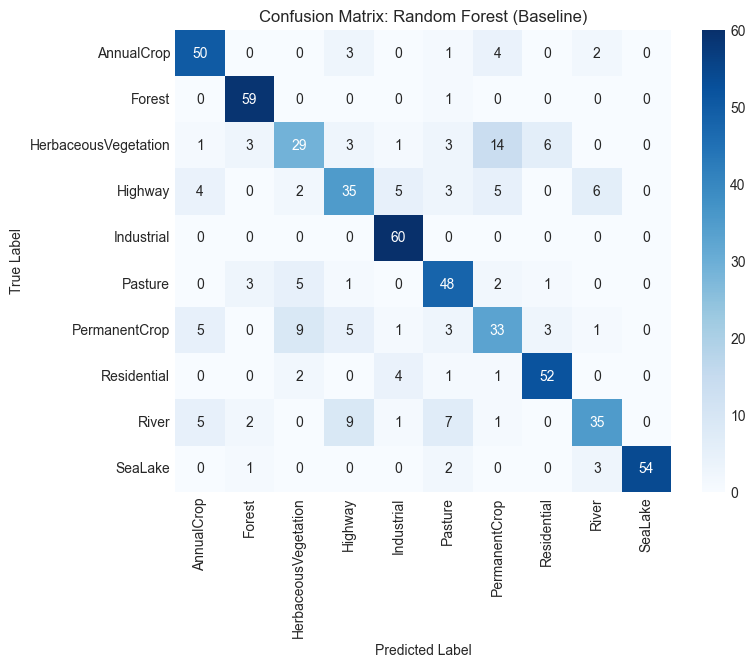

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)

print("--- Classical ML (Random Forest) Results ---\n")
print(classification_report(y_test, y_pred, target_names=class_names))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Random Forest (Baseline)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 3. Track B: Deep Learning (Transfer Learning with CNN)
Utilizing a pre-trained ResNet18 model with data augmentation to automatically extract hierarchical spatial features.

In [6]:
# Transforms: Augmentation for training, simple normalization for testing
train_transforms = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = ImageFolder(DATA_DIR, transform=train_transforms)
class_names_dl = full_dataset.classes

# Split into train and test
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

# Override transforms for test dataset
test_dataset.dataset.transform = test_transforms

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"DL Pipeline: {len(train_dataset)} training images, {len(test_dataset)} testing images.")

DL Pipeline: 21600 training images, 5400 testing images.


In [7]:
from torchvision.models import resnet18, ResNet18_Weights

# Load pre-trained ResNet18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Modify the final classification layer for 10 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\wojci/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 40.2MB/s]


Linear(in_features=512, out_features=10, bias=True)


In [ ]:
num_epochs = 5

print("--- Training Deep Learning Model ---")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(train_loader):.4f} - Acc: {100 * correct / total:.2f}%")

# Evaluation
model.eval()
y_true_dl, y_pred_dl = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        y_true_dl.extend(labels.numpy())
        y_pred_dl.extend(predicted.cpu().numpy())

print("\n--- Deep Learning (ResNet18) Results ---")
print(classification_report(y_true_dl, y_pred_dl, target_names=class_names_dl))

plt.figure(figsize=(8, 6))
cm_dl = confusion_matrix(y_true_dl, y_pred_dl)
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names_dl, yticklabels=class_names_dl)
plt.title('Confusion Matrix: ResNet18 (Track B)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

--- Training Deep Learning Model ---
Epoch 1/5 - Loss: 0.3826 - Acc: 88.05%
